In [1]:
import os
import pickle

import matplotlib
import numpy as np
import pandas as pd
import FinanceDataReader as fdr
import matplotlib.dates as mdates
import ustreasurycurve as ustcurve

from collections import namedtuple
from Library.Interpolation import pchip_interpolator2d
from Library.RiskEngineKimYi2025 import *
from Library.PayoffFactory import *
from Library.OptionPricerBSM1973 import *
from Library.ExoticEngine import *
from Library.Utility import UST_TENOR_MAP, year_frac, get_fixings_vec
from Library.StatisticsMC import StatisticsMCMean, StatisticsMCQuantile
from Library.PathDependent import PathDependentAsianDiscrete
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on NumPy v{np.__version__}")

Running on PyMC v5.22.0
Running on NumPy v2.2.4


In [2]:
# inputs
valuation_beg_date = '20250331'
valuation_end_date = '20250417'

UND_TICKERS_DICT = {'systematic': '^SPX', 'idiosyncratic': ['COIN']}
SET_OF_TICKERS = [UND_TICKERS_DICT['systematic']] + [*UND_TICKERS_DICT['idiosyncratic']]

DIVIDEND_YIELDS = {'^SPX': 1.25, 'COIN': 0.}

origin_date = (pd.to_datetime(valuation_beg_date) - pd.Timedelta(730, "D")).strftime("%Y%m%d")
total_date_set = pd.bdate_range(origin_date, valuation_end_date)
valuation_date_array = pd.bdate_range(valuation_beg_date, pd.to_datetime(valuation_end_date))

In [3]:
template_df = pd.DataFrame(index=total_date_set)
template_df.index.name = 'dtDATE'

df = []
for ticker in SET_OF_TICKERS:
    df_ = fdr.DataReader(ticker)
    df_.index.name = 'dtDATE'
    df_.index = pd.to_datetime(df_.index)
    df_.reset_index(inplace=True)
    df_["sSYMBOL"] = ticker
    df.append(df_)
df = pd.concat(df)
df.set_index('sSYMBOL', inplace=True)

prices_df = template_df.join(df.pivot_table(index='dtDATE', columns='sSYMBOL', values='Adj Close')).ffill().bfill()
volume_df = template_df.join(df.pivot_table(index='dtDATE', columns='sSYMBOL', values='Volume')).ffill().bfill()

return_df = prices_df.sort_index().pct_change().fillna(0.)

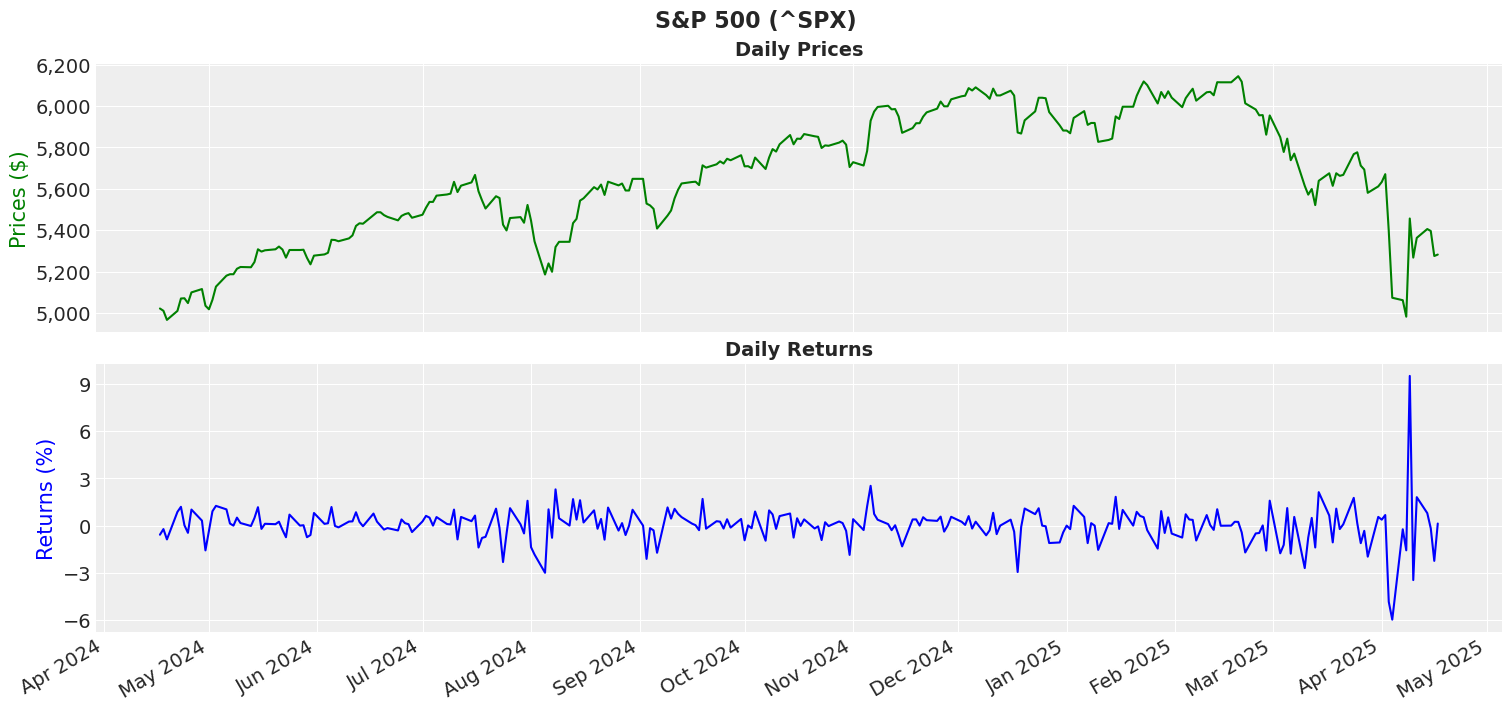

In [4]:
fig, ax = plt.subplots(nrows=2, figsize=(15, 7))

t1 = total_date_set.max() - pd.DateOffset(years=1)
t2 = total_date_set.max()

sns.lineplot(data=prices_df.loc[t1:t2, SET_OF_TICKERS[0]].reset_index(), x='dtDATE', y=SET_OF_TICKERS[0], color='green', ax=ax[0])
sns.lineplot(data=return_df.loc[t1:t2, SET_OF_TICKERS[0]].multiply(100.).reset_index(), x='dtDATE', y=SET_OF_TICKERS[0], color='blue', ax=ax[1])

ax[1].set_xlabel(None)
ax[0].set_ylabel('Prices ($)', color='green')
ax[1].set_ylabel('Returns (%)', color='blue')
ax[0].set_title(f'Daily Prices', fontsize=14, fontweight='bold')
ax[1].set_title(f'Daily Returns', fontsize=14, fontweight='bold')
ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax[0].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(200))
ax[1].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(3))

fig.suptitle(f"S&P 500 ({SET_OF_TICKERS[0]})", fontsize=16, fontweight='bold')
fig.autofmt_xdate()

plt.savefig("daily_prices_returns_SPX.pdf", dpi=300)
plt.show();

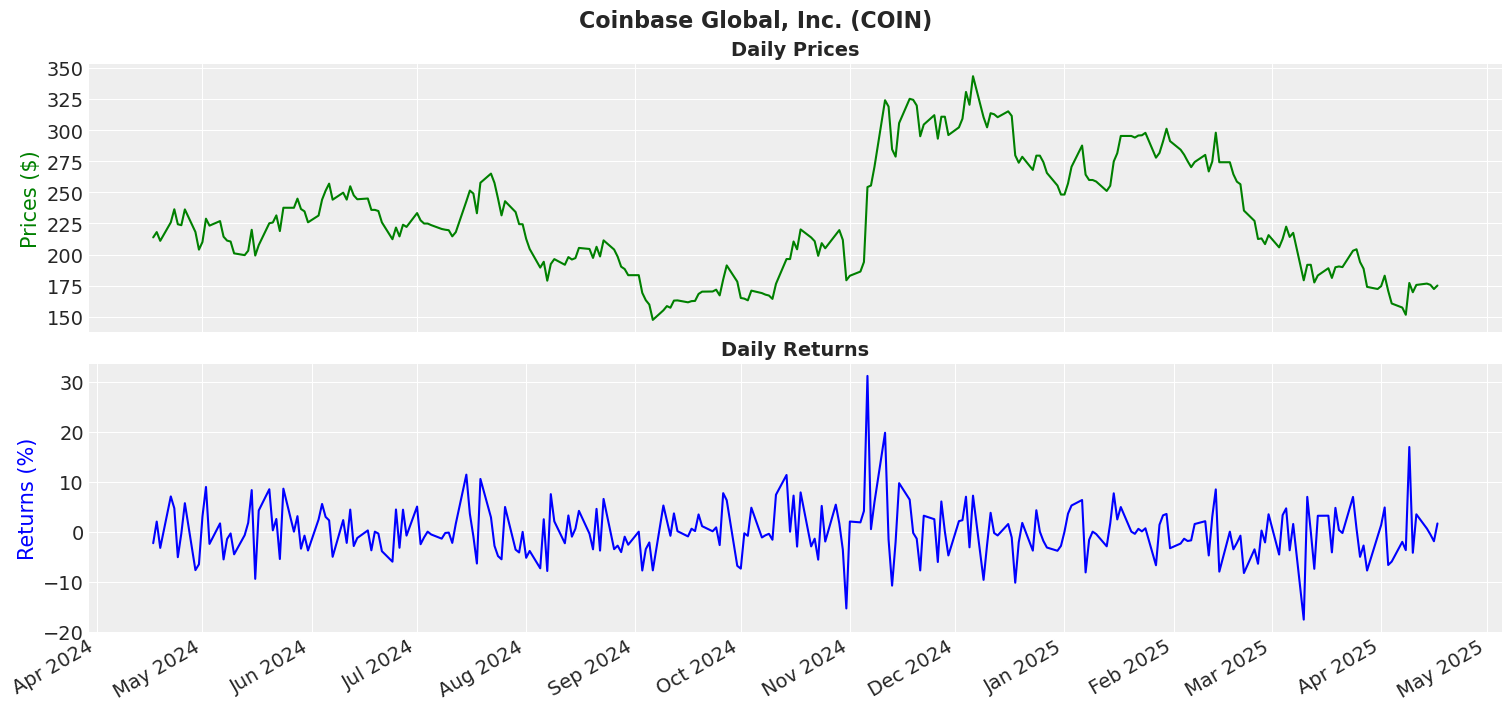

In [5]:
fig, ax = plt.subplots(nrows=2, figsize=(15, 7))

t1 = total_date_set.max() - pd.DateOffset(years=1)
t2 = total_date_set.max()

sns.lineplot(data=prices_df.loc[t1:t2, SET_OF_TICKERS[-1]].reset_index(), x='dtDATE', y=SET_OF_TICKERS[-1], color='green', ax=ax[0])
sns.lineplot(data=return_df.loc[t1:t2, SET_OF_TICKERS[-1]].multiply(100.).reset_index(), x='dtDATE', y=SET_OF_TICKERS[-1], color='blue', ax=ax[1])

ax[1].set_xlabel(None)
ax[0].set_ylabel('Prices ($)', color='green')
ax[1].set_ylabel('Returns (%)', color='blue')
ax[0].set_title(f'Daily Prices', fontsize=14, fontweight='bold')
ax[1].set_title(f'Daily Returns', fontsize=14, fontweight='bold')

ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax[0].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(25))

fig.suptitle(f"Coinbase Global, Inc. ({SET_OF_TICKERS[-1]})", fontsize=16, fontweight='bold')
fig.autofmt_xdate()

plt.savefig(f"daily_prices_returns_{SET_OF_TICKERS[-1]}.pdf", dpi=300)
plt.show();

In [6]:
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.bdate_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-31,4.38,4.36,4.35,4.32,4.31,4.23,4.03,3.89,3.89,3.96,4.09,4.23,4.62,4.59
2025-04-01,4.38,4.36,4.35,4.32,4.30,4.23,4.01,3.87,3.85,3.91,4.03,4.17,4.56,4.52
2025-04-02,4.38,4.36,4.34,4.32,4.32,4.24,4.04,3.91,3.89,3.95,4.07,4.20,4.58,4.54
2025-04-03,4.36,4.37,4.38,4.31,4.29,4.20,3.92,3.71,3.68,3.75,3.88,4.06,4.51,4.49
2025-04-04,4.36,4.35,4.36,4.28,4.25,4.14,3.86,3.68,3.66,3.72,3.84,4.01,4.44,4.41


In [61]:
try:
    # Open the file in binary read mode ('rb')
    file_path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), os.pardir)), rf'Vol Surface From Model/kimyi2025_vol_surface.pkl')
    with open(file_path, 'rb') as file:
        # Load the pickled data
        vol_surf_df = pickle.load(file)

    # Now, 'loaded_data' contains the Python object that was saved
    print("Data successfully loaded from pickle file:")
    print(file_path)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")


Data successfully loaded from pickle file:
/home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Vol Surface From Model/kimyi2025_vol_surface.pkl


In [62]:
def generate_und_dt_key(underlying_name: str, valuation_date: str) -> str:
    return f"{underlying_name}-{valuation_date}"

In [63]:
valuation_date = '20250409'
lookback_period = 252
returns_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date)].pct_change()
returns_df = returns_df.iloc[-lookback_period:]

underlying_name = UND_TICKERS_DICT['systematic']

returns = returns_df[underlying_name].to_numpy()
base_days = 252

delta_t = np.array(1 / base_days)

params_dict = {}

key = generate_und_dt_key(underlying_name, valuation_date)

params_dict[key] = pmle_kimyirisk_systematic(sys_returns=returns, delta_t=delta_t)

sys_params = params_dict[key]

underlying_name = UND_TICKERS_DICT["idiosyncratic"][0]

returns = returns_df[underlying_name].to_numpy()

key = generate_und_dt_key(underlying_name, valuation_date)

params_dict[key] = pmle_kimyirisk_idiosyncratic(idi_returns=returns, params_sys=sys_params, delta_t=delta_t)

params_dict

{'^SPX-20250409': {'dALPHA': ParamsResult(dMEAN=np.float64(0.6804506362045877), dCI_LOWER=np.float64(0.42147281477591764), dCI_UPPER=np.float64(0.9910403787728836)),
  'dSIGMA': ParamsResult(dMEAN=np.float64(0.167), dCI_LOWER=np.float64(0.153), dCI_UPPER=np.float64(0.182)),
  'dPPROB': ParamsResult(dMEAN=np.float64(0.4399914429939336), dCI_LOWER=np.float64(0.21849328438476318), dCI_UPPER=np.float64(0.8344353586957896)),
  'dLAMB': ParamsResult(dMEAN=np.float64(10.192), dCI_LOWER=np.float64(4.97), dCI_UPPER=np.float64(15.808)),
  'dETA1': ParamsResult(dMEAN=np.float64(50.517), dCI_LOWER=np.float64(37.502), dCI_UPPER=np.float64(63.94)),
  'dETA2': ParamsResult(dMEAN=np.float64(25.855), dCI_LOWER=np.float64(17.092), dCI_UPPER=np.float64(35.353))},
 'COIN-20250409': {'dMUI': ParamsResult(dMEAN=np.float64(0.208), dCI_LOWER=np.float64(-0.794), dCI_UPPER=np.float64(1.212)),
  'dKAPPAI': ParamsResult(dMEAN=np.float64(0.5262388930771054), dCI_LOWER=np.float64(0.22672895630607542), dCI_UPPER=np.

In [64]:
def kimyi2025_pmle_helper(risk_horizon, base_days: int = 252) -> str:

    Delta_t = np.array(risk_horizon / base_days)
    days_to_look_back = base_days

    pmle_params_sys_df = []
    pmle_params_idi_df = []

    # P-MLE for Systematic Asset
    underlying_name = SET_OF_TICKERS[0]
    PATH = os.path.join(os.path.abspath(os.path.join(os.getcwd(), os.pardir)), rf'Estimated Parameters PMLE/{underlying_name}')
    print(PATH)
    for valuation_date in valuation_date_array:
        filename= f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'
        print(filename)
        if filename in os.listdir(PATH):
            pmle_params_sys_df.append(pd.read_csv(os.path.join(PATH, filename)))
        else:
            valuation_date_str = valuation_date.strftime("%Y-%m-%d")
            tmp_return_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date_str)].pct_change(periods=risk_horizon)
            return_df = tmp_return_df.iloc[-days_to_look_back:]
            sys_returns_df = return_df[underlying_name]
            tmp_df = pmle_kimyirisk_systematic(
                valuation_date=valuation_date_str,
                sys_returns_df=sys_returns_df,
                delta_t=Delta_t
            )
            pmle_params_sys_df.append(tmp_df)
            tmp_df.to_csv(os.path.join(PATH, f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'), index=False)

    pmle_params_sys_df = pd.concat(pmle_params_sys_df)
    pmle_params_sys_df.dtVALUATION_DATE = pd.to_datetime(pmle_params_sys_df.dtVALUATION_DATE)

    # P-MLE for Idiosyncratic Asset
    for underlying_name in SET_OF_TICKERS[1:]:
        PATH = os.path.join(os.path.abspath(os.path.join(os.getcwd(), os.pardir)), rf'Estimated Parameters PMLE/{underlying_name}')
        print(PATH)
        for valuation_date in valuation_date_array:
            filename= f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'
            print(filename)
            if filename in os.listdir(PATH):
                pmle_params_idi_df.append(pd.read_csv(os.path.join(PATH, filename)))
            else:
                valuation_date_str = valuation_date.strftime("%Y-%m-%d")
                tmp_return_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date_str)].pct_change(periods=risk_horizon)
                return_df = tmp_return_df.iloc[-days_to_look_back:]
                idi_returns_df = return_df[underlying_name]
                tmp_df = pmle_kimyirisk_idiosyncratic(
                    valuation_date=valuation_date_str,
                    idi_returns_df=idi_returns_df,
                    params_sys_df=pmle_params_sys_df.set_index('dtVALUATION_DATE').xs(valuation_date),
                    delta_t=Delta_t
                )
                pmle_params_idi_df.append(tmp_df)
                tmp_df.to_csv(os.path.join(PATH, f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'), index=False)
    # pmle_params_idi_df = pd.concat(pmle_params_idi_df)
    # pmle_params_idi_df.dtVALUATION_DATE = pd.to_datetime(pmle_params_idi_df.dtVALUATION_DATE)
    # pmle_params_df = pd.concat([pmle_params_sys_df, pmle_params_idi_df]).set_index(['dtVALUATION_DATE', 'sUNDERLYING_NAME'])
    return f"Completed successfully P-MLE exercise given {risk_horizon}-days risk horizon."

def get_pmle_estimated_params() -> pd.DataFrame:
    df = []
    for underlying_name in SET_OF_TICKERS:
        PATH = os.path.join(os.path.abspath(os.path.join(os.getcwd(), os.pardir)), rf'Estimated Parameters PMLE/{underlying_name}')
        for file_name in os.listdir(PATH):
            print(file_name)
            file_name = os.path.join(PATH, file_name)
            tmp_df = pd.read_csv(file_name)
            df.append(tmp_df)
    df = pd.concat(df)
    df.dtVALUATION_DATE = pd.to_datetime(df.dtVALUATION_DATE)
    return df.set_index(['dtVALUATION_DATE', 'sUNDERLYING_NAME'])

In [65]:
risk_horizons = [1]

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results = executor.map(kimyi2025_pmle_helper, risk_horizons)

        for i, result in enumerate(results):
            print(f"{i}: {result}")

/home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Estimated Parameters PMLE/^SPX
estimated_params_pmle_^SPX_20250331.csv
estimated_params_pmle_^SPX_20250401.csv
estimated_params_pmle_^SPX_20250402.csv
estimated_params_pmle_^SPX_20250403.csv
estimated_params_pmle_^SPX_20250404.csv
estimated_params_pmle_^SPX_20250407.csv
estimated_params_pmle_^SPX_20250408.csv
estimated_params_pmle_^SPX_20250409.csv
estimated_params_pmle_^SPX_20250410.csv
estimated_params_pmle_^SPX_20250411.csv
estimated_params_pmle_^SPX_20250414.csv
estimated_params_pmle_^SPX_20250415.csv
estimated_params_pmle_^SPX_20250416.csv
estimated_params_pmle_^SPX_20250417.csv
/home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Estimated Parameters PMLE/COIN
estimated_params_pmle_COIN_20250331.csv
estimated_params_pmle_COIN_20250401.csv
estimated_params_pmle_COIN_20250402.csv
estimated_params_pmle_COIN_20250403.csv
estimated_params_pmle_COIN_20250404.csv
estimated_params_pmle_COIN_20250407.csv
estimated_params_pml

In [67]:
mask = pmle_params_df.index.get_level_values("sUNDERLYING_NAME")!=UND_TICKERS_DICT['systematic']
pmle_params_tmp_df = pmle_params_df[mask]
rhoix  = (pmle_params_tmp_df.dSIGMA * pmle_params_tmp_df.dBETAI)**2
rhoix += 2 * pmle_params_tmp_df.dSIGMA * pmle_params_tmp_df.dBETAI * pmle_params_tmp_df.dKAPPAI * pmle_params_tmp_df.dRHOIX
rhoix += pmle_params_tmp_df.dKAPPAI**2
rhoix **=(1/2)
rhoix
# rhoix.loc[rhoix.index.get_level_values('sUNDERLYING_NAME')!=UND_TICKERS_DICT['systematic']]

dtVALUATION_DATE  sUNDERLYING_NAME
2025-04-16        COIN                0.748417
2025-04-04        COIN                0.748388
2025-03-31        COIN                0.749960
2025-04-01        COIN                0.745666
2025-04-17        COIN                0.745671
2025-04-10        COIN                0.755465
2025-04-07        COIN                0.746185
2025-04-03        COIN                0.747767
2025-04-15        COIN                0.750279
2025-04-11        COIN                0.752031
2025-04-02        COIN                0.745190
2025-04-09        COIN                0.755058
2025-04-08        COIN                0.745194
2025-04-14        COIN                0.752213
dtype: float64

In [68]:
def simulate_shock_returns(params: pd.Series, rng: RandomBase, risk_horizon: int, size: Tuple[int, int, int], base_days: int = 252) -> NDArray[np.float64]:

    ret, _, _ = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI_CI_LOWER)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(params.dGAMMAI)],
        betai=[ParametersConstant(params.dBETAI)],
        rhoix=[ParametersConstant(params.dRHOIX)],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=np.array(risk_horizon / base_days)
    ).random(rng=rng, size=size)

    return ret[0]

def simulate_shock_returns_base(params: pd.Series, rng: RandomBase, risk_horizon: int, size: Tuple[int, int, int], base_days: int = 252) -> NDArray[np.float64]:

    ret, _, _ = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(np.array(.0))],
        betai=[ParametersConstant(np.array(.0))],
        rhoix=[ParametersConstant(np.array(.0))],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=np.array(risk_horizon / base_days)
    ).random(rng=rng, size=size)

    return ret[0]

def est_liquidity_process(params: pd.Series, observed_data: NDArray[np.float64], risk_horizon: int, base_days: int = 252) -> NDArray[np.float64]:

    Psi = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(params.dGAMMAI)],
        betai=[ParametersConstant(params.dBETAI)],
        rhoix=[ParametersConstant(params.dRHOIX)],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=np.array(risk_horizon / base_days)
    ).est_liquidity_process(observed_data)

    return Psi

In [69]:
n_paths = 10_000
m_steps = 20
h = 1
seed_number = 20251231

def simulate_shock_returns_helper(valuation_date: str) -> dict:

    output = {}
    for underlying_name in SET_OF_TICKERS:
        output[underlying_name] = simulate_shock_returns(
            pmle_params_df.xs(pd.to_datetime(valuation_date, format="%Y%m%d")).xs(underlying_name), RandomMT19937(np.uint64(seed_number)), h, (1, n_paths, m_steps)
        )

    return {valuation_date: output}


def simulate_shock_returns_base_helper(valuation_date: str) -> dict:

    output = {}
    for underlying_name in SET_OF_TICKERS:
        output[underlying_name] = simulate_shock_returns_base(
            pmle_params_df.xs(pd.to_datetime(valuation_date, format="%Y%m%d")).xs(underlying_name), RandomMT19937(np.uint64(seed_number)), h, (1, n_paths, m_steps)
        )

    return {valuation_date: output}


def est_liquidity_process_helper(valuation_date: str) -> dict:
    tmp_return_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date)].pct_change(periods=h)
    tmp_return = tmp_return_df.iloc[-252:]

    output = {}
    for underlying_name in SET_OF_TICKERS:
        output[underlying_name] = est_liquidity_process(
            pmle_params_df.xs(pd.to_datetime(valuation_date, format="%Y%m%d")).xs(underlying_name), tmp_return[underlying_name].to_numpy()[1:].reshape((-1, 1)), h
        )

    return {valuation_date: output}

In [ ]:
simulate_shock_returns(

)

In [98]:
if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    valuation_dates = [date.strftime("%Y%m%d") for date in valuation_date_array]

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(simulate_shock_returns_helper, valuation_dates)
        results2 = executor.map(simulate_shock_returns_base_helper, valuation_dates)
        results3 = executor.map(est_liquidity_process_helper, valuation_dates)

        shock_returns_dict = {}
        shock_returns_base_dict = {}
        liquidity_process_dict = {}

        for result1 in results1:
            for date_key, inner_dict in result1.items():
                shock_returns_dict[date_key] = inner_dict

        for result2 in results2:
            for date_key, inner_dict in result2.items():
                shock_returns_base_dict[date_key] = inner_dict

        for result3 in results3:
            for date_key, inner_dict in result3.items():
                liquidity_process_dict[date_key] = inner_dict

In [100]:
shock_returns_dict['20250409']['COIN']

array([[ 0.        , -0.06808521, -0.01956175, ..., -0.00263767,
        -0.0838329 , -0.00429541],
       [ 0.        , -0.0816847 ,  0.01481242, ..., -0.03318207,
         0.01090809,  0.01549343],
       [ 0.        , -0.02510747, -0.04023335, ...,  0.10766945,
         0.04715896, -0.04530937],
       ...,
       [ 0.        , -0.06564373, -0.05462761, ...,  0.0126387 ,
         0.05419839, -0.04608539],
       [ 0.        , -0.00946483,  0.01505432, ..., -0.01633772,
        -0.05487722, -0.07963693],
       [ 0.        , -0.05005095, -0.03821956, ..., -0.07915176,
        -0.06813484,  0.06839202]], shape=(10000, 21))

In [71]:
df1 = pd.DataFrame(data=shock_returns_dict['20250409']['COIN'][:, :2].sum(axis=1) * 100., columns=['dSIMULATED_RETURNS'])
df2 = pd.DataFrame(data=shock_returns_base_dict['20250409']['COIN'][:, :2].sum(axis=1) * 100., columns=['dSIMULATED_RETURNS'])
df1['Return Assumption'] = 'LA'
df2['Return Assumption'] = 'BS'
simulated_returns_df = pd.concat([df1, df2])
simulated_returns_df = simulated_returns_df.set_index('Return Assumption')

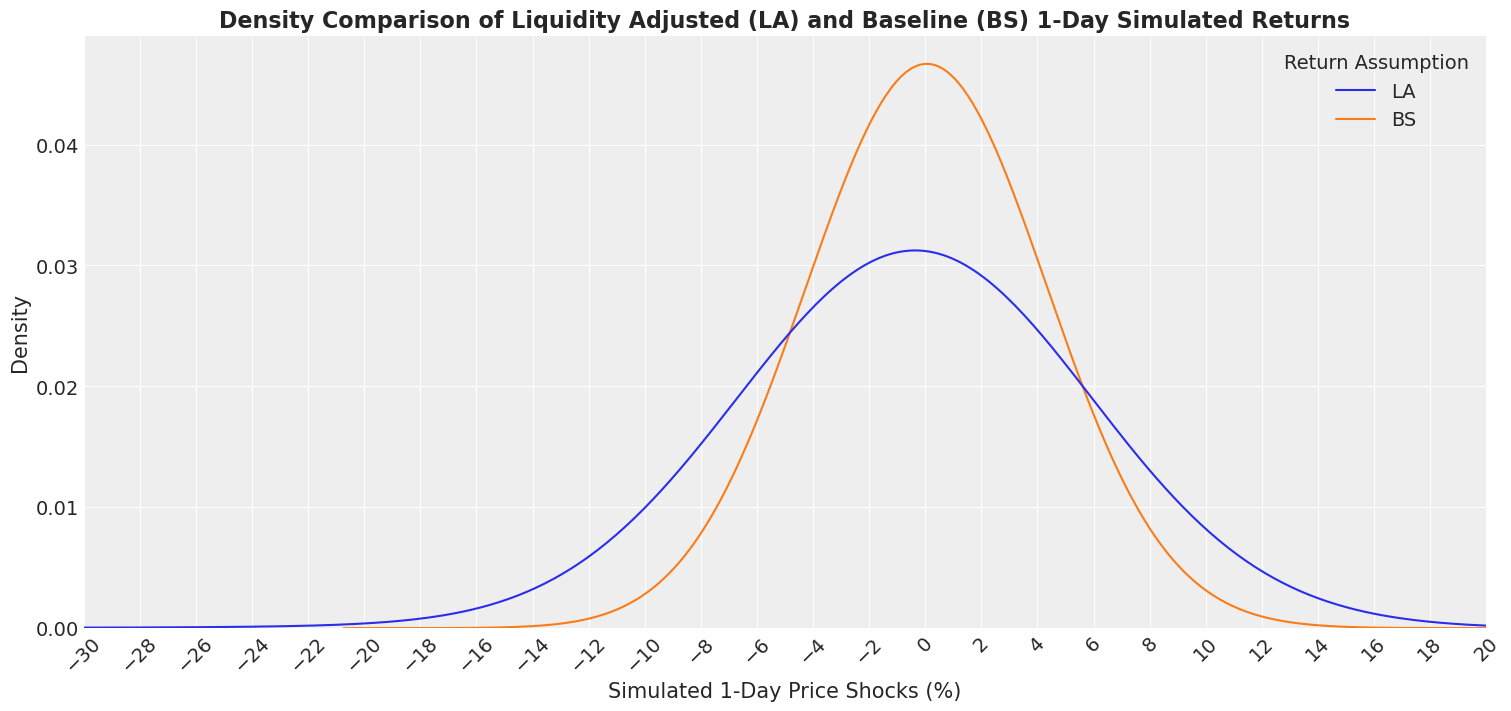

In [72]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.kdeplot(data=simulated_returns_df, x='dSIMULATED_RETURNS', hue='Return Assumption', fill=False, gridsize=500, bw_adjust=5., ax=ax)
# sns.kdeplot(data=simulated_returns_df, x='dSIMULATED_RETURNS', hue='Return Assumption', fill=True, alpha=.4, gridsize=1_000, ax=ax)

# ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.tick_params(axis='x', which='both', labelrotation=45)

ax.set_title(f'Density Comparison of Liquidity Adjusted (LA) and Baseline (BS) {h}-Day Simulated Returns', fontweight='bold')
ax.set_xlabel(f"Simulated {h}-Day Price Shocks (%)")

plt.setp(ax.get_legend().get_title(), fontsize='14')
plt.xlim(-30, 20)
plt.savefig("density_simulated_returns.pdf", dpi=300)
plt.show()

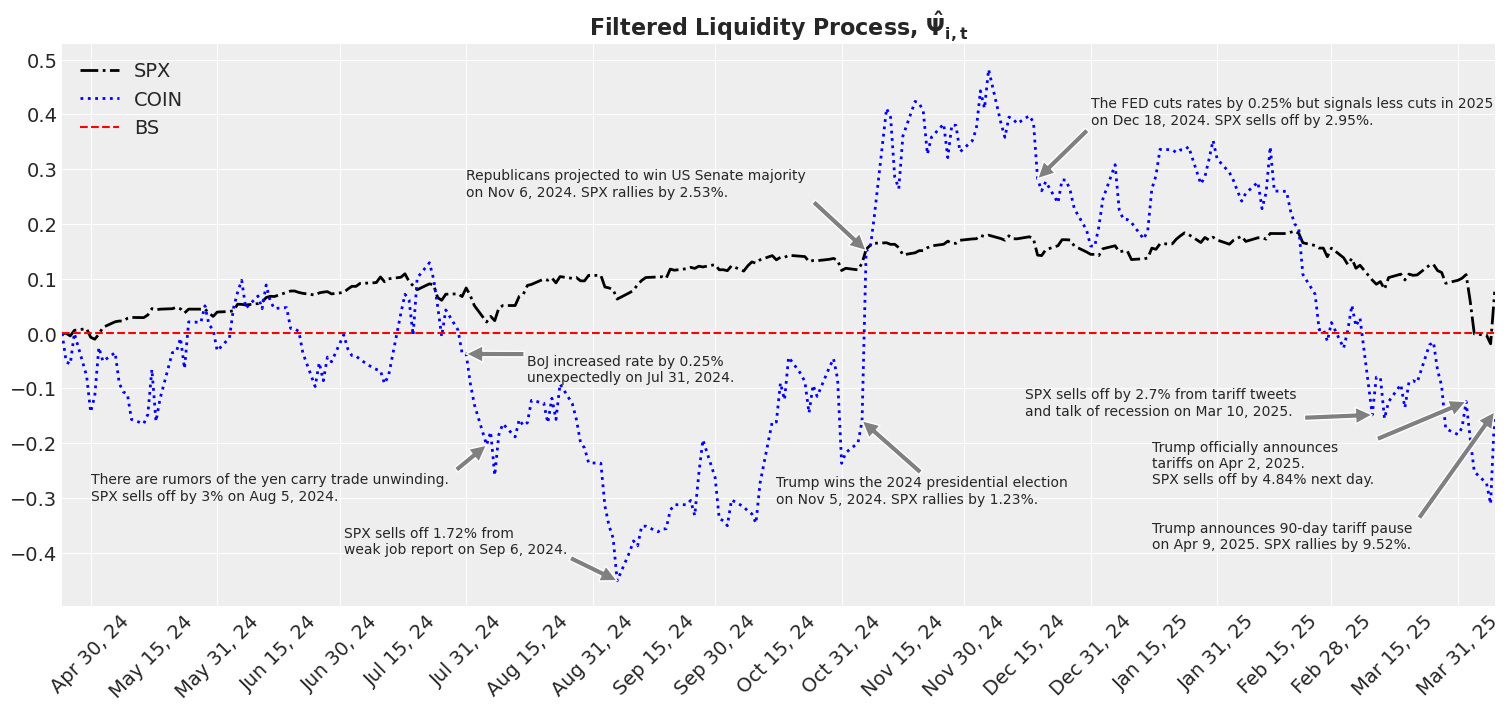

In [73]:
# liquidity process for last date
valuation_date_str = '20250409'

index = return_df.loc[return_df.index <= pd.to_datetime(valuation_date_str)].iloc[-252:].index

liquidity_process_df = pd.concat(
    [
        pd.Series(liquidity_process_dict[valuation_date_str][SET_OF_TICKERS[0]].squeeze(), index=index, name=SET_OF_TICKERS[0]),
        pd.Series(liquidity_process_dict[valuation_date_str][SET_OF_TICKERS[1]].squeeze(), index=index, name=SET_OF_TICKERS[1])
    ],
    axis=1
)

fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(x=liquidity_process_df.index, y=liquidity_process_df[SET_OF_TICKERS[0]].squeeze(), ax=ax, label=rf'{SET_OF_TICKERS[0].split("^")[1]}', color='black', linestyle='-.', linewidth=2)
sns.lineplot(x=liquidity_process_df.index, y=liquidity_process_df[SET_OF_TICKERS[1]].squeeze(), ax=ax, label=rf'{SET_OF_TICKERS[1]}', color='blue', linestyle=':', linewidth=2)
sns.lineplot(x=liquidity_process_df.index, y=0, ax=ax, color='red', linestyle='--', linewidth=1.5, label='BS')

ax.set_xlabel(None)
ax.set_ylabel(None)
# ax.legend(title='Underlying Tickers', title_fontproperties={'weight': 'bold', 'size': 'large'})
ax.set_title(r'Filtered Liquidity Process, $\mathbf{{\hat{\Psi}_{{i, t}}}}$', fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=-1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %y'))
ax.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b %d, %y'))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(.1))

ax.tick_params(axis='x', which='both', labelrotation=45)

ax.annotate(
    text="BoJ increased rate by 0.25% \nunexpectedly on Jul 31, 2024.",
    xy=(pd.to_datetime('20240731'), liquidity_process_df.xs('20240731')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20240815'), liquidity_process_df.xs('20240731')[SET_OF_TICKERS[1]] - .05),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="There are rumors of the yen carry trade unwinding. \nSPX sells off by 3% on Aug 5, 2024.",
    xy=(pd.to_datetime('20240805'), liquidity_process_df.xs('20240805')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20240430'), liquidity_process_df.xs('20240805')[SET_OF_TICKERS[1]] - .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="SPX sells off 1.72% from \nweak job report on Sep 6, 2024.",
    xy=(pd.to_datetime('20240906'), liquidity_process_df.xs('20240906')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20240701'), liquidity_process_df.xs('20240906')[SET_OF_TICKERS[1]] + .05),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump wins the 2024 presidential election \non Nov 5, 2024. SPX rallies by 1.23%.",
    xy=(pd.to_datetime('20241105'), liquidity_process_df.xs('20241105')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20241015'), liquidity_process_df.xs('20241105')[SET_OF_TICKERS[1]] - .15),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Republicans projected to win US Senate majority \non Nov 6, 2024. SPX rallies by 2.53%.",
    xy=(pd.to_datetime('20241106'), liquidity_process_df.xs('20241106')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20240731'), liquidity_process_df.xs('20241106')[SET_OF_TICKERS[1]] + .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="The FED cuts rates by 0.25% but signals less cuts in 2025 \non Dec 18, 2024. SPX sells off by 2.95%.",
    xy=(pd.to_datetime('20241218'), liquidity_process_df.xs('20241218')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20241231'), liquidity_process_df.xs('20241218')[SET_OF_TICKERS[1]] + .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="SPX sells off by 2.7% from tariff tweets \nand talk of recession on Mar 10, 2025.",
    xy=(pd.to_datetime('20250310'), liquidity_process_df.xs('20250310')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20241215'), liquidity_process_df.xs('20250310')[SET_OF_TICKERS[1]]),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump officially announces \ntariffs on Apr 2, 2025. \nSPX sells off by 4.84% next day.",
    xy=(pd.to_datetime('20250402'), liquidity_process_df.xs('20250402')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20250115'), liquidity_process_df.xs('20250402')[SET_OF_TICKERS[1]] - .15),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump announces 90-day tariff pause \non Apr 9, 2025. SPX rallies by 9.52%.",
    xy=(pd.to_datetime('20250409'), liquidity_process_df.xs('20250409')[SET_OF_TICKERS[1]]),
    xytext=(pd.to_datetime('20250115'), liquidity_process_df.xs('20250409')[SET_OF_TICKERS[1]] - .25),
    arrowprops=dict(facecolor='grey')
)

# plt.tight_layout()
plt.xlim(index[0], index[-1])
plt.savefig("filtered_liquidity_process.pdf", dpi=300)
plt.show();

In [74]:
portfolio_pos_names_list = [
    'sVALUATION_DATE',
    'sUNDERLYING',
    'sSTRATEGY',
    'sTYPOLOGY',
    'sPAYOFF',
    'sEXPIRY_DATE',
    'dSTRIKE_PRICE',
    'iQUANTITY',
    'sFIXING_DATE_BEG',
    'sFIXING_DATE_END',
    'iBASE_DAYS',
    'dSPOT_PRICE',
    'dVOL_SURFACE',
    'dDIVIDEND_YIELD',
    'oRISK_FREE_RATE_TERM'
]

PortfolioPos = namedtuple('PortfolioPos', portfolio_pos_names_list)

iBASE_DAYS = np.int64(252)

portfolio_pos_dict = {}

valuation_start_date = '20250331'

for valuation_date in valuation_date_array:

    valuation_date_str = valuation_date.strftime("%Y%m%d")

    portfolio_inner_dict = {}

    for underlying_name in SET_OF_TICKERS[1:]:

        spot_price = prices_df.xs(valuation_date_str)[underlying_name]
        id = f"{underlying_name}-{valuation_date_str}"
        vol_surface = pd.DataFrame(data=vol_surf_df[id]['dVOL'], index=vol_surf_df[id]['iEXPIRY'], columns=vol_surf_df[id]['dMONEYNESS'] * 100.)

        rates_data = rates_data_df.xs(valuation_date)
        tenors = np.array([UST_TENOR_MAP[tenor] for tenor in rates_data.index]).squeeze()
        rates = rates_data.to_numpy().squeeze() / 100.
        curve_fit, _ = calibrate_nss_ols(tenors, rates)

        # product detail
        fixing_date_beg_str = (valuation_date_array[0] + pd.Timedelta(days=1)).strftime("%Y%m%d")
        fixing_date_end_str = valuation_date_array[-1]
        expiry_date_str = (valuation_date_array[-1] + pd.Timedelta(days=1)).strftime("%Y%m%d")

        dividend_yield = np.array(DIVIDEND_YIELDS[underlying_name] / 100.)

        portfolio_inner_dict[underlying_name] = [
            PortfolioPos(
                sVALUATION_DATE=valuation_date_str, sUNDERLYING=underlying_name, sSTRATEGY='collar', sTYPOLOGY='asian discrete', sPAYOFF='put',
                sEXPIRY_DATE=expiry_date_str, dSTRIKE_PRICE=np.round(prices_df.xs(valuation_start_date)[underlying_name], 4), iQUANTITY=np.int64(-100), sFIXING_DATE_BEG=fixing_date_beg_str, sFIXING_DATE_END=fixing_date_end_str, iBASE_DAYS=iBASE_DAYS,
                dSPOT_PRICE=spot_price, dVOL_SURFACE=vol_surface, dDIVIDEND_YIELD=dividend_yield, oRISK_FREE_RATE_TERM=curve_fit
            ),
            PortfolioPos(
                sVALUATION_DATE=valuation_date_str, sUNDERLYING=underlying_name, sSTRATEGY='collar', sTYPOLOGY='asian discrete', sPAYOFF='call',
                sEXPIRY_DATE=expiry_date_str, dSTRIKE_PRICE=np.round(prices_df.xs(valuation_start_date)[underlying_name] * 1.15, 4), iQUANTITY=np.int64(100), sFIXING_DATE_BEG=fixing_date_beg_str, sFIXING_DATE_END=fixing_date_end_str, iBASE_DAYS=iBASE_DAYS,
                dSPOT_PRICE=spot_price, dVOL_SURFACE=vol_surface, dDIVIDEND_YIELD=dividend_yield, oRISK_FREE_RATE_TERM=curve_fit
            ),
            PortfolioPos(
                sVALUATION_DATE=valuation_date_str, sUNDERLYING=underlying_name, sSTRATEGY='hedge', sTYPOLOGY='vanilla', sPAYOFF='put',
                sEXPIRY_DATE=expiry_date_str, dSTRIKE_PRICE=np.round(prices_df.xs(valuation_start_date)[underlying_name] * 1.05, 4), iQUANTITY=np.int64(85), sFIXING_DATE_BEG=None, sFIXING_DATE_END=None, iBASE_DAYS=iBASE_DAYS,
                dSPOT_PRICE=spot_price, dVOL_SURFACE=vol_surface, dDIVIDEND_YIELD=dividend_yield, oRISK_FREE_RATE_TERM=curve_fit
            ),
            PortfolioPos(
                sVALUATION_DATE=valuation_date_str, sUNDERLYING=underlying_name, sSTRATEGY='hedge', sTYPOLOGY='vanilla', sPAYOFF='call',
                sEXPIRY_DATE=expiry_date_str, dSTRIKE_PRICE=np.round(prices_df.xs(valuation_start_date)[underlying_name] * 1.2, 4), iQUANTITY=np.int64(-120), sFIXING_DATE_BEG=None, sFIXING_DATE_END=None, iBASE_DAYS=iBASE_DAYS,
                dSPOT_PRICE=spot_price, dVOL_SURFACE=vol_surface, dDIVIDEND_YIELD=dividend_yield, oRISK_FREE_RATE_TERM=curve_fit
            )
        ]

    portfolio_pos_dict[valuation_date_str] = portfolio_inner_dict

In [75]:
portfolio_risk_names_list = [
    'sVALUATION_DATE',
    'sUNDERLYING',
    'iRISK_HORIZON_DAYS',
    'dSHOCKS'
]

PortfolioRisk = namedtuple("PortfolioRisk", portfolio_risk_names_list)

iRISK_HORIZON_DAYS = np.int64(1)

portfolio_risk_dict = {}

for valuation_date in valuation_date_array:

    valuation_date_str = valuation_date.strftime("%Y%m%d")

    portfolio_inner_dict = {}

    for underlying_name in SET_OF_TICKERS[1:]:

        portfolio_inner_dict[underlying_name] = PortfolioRisk(
            sVALUATION_DATE=valuation_date_str,
            sUNDERLYING=underlying_name,
            iRISK_HORIZON_DAYS=iRISK_HORIZON_DAYS,
            dSHOCKS=shock_returns_dict[valuation_date_str][underlying_name]
        )

    portfolio_risk_dict[valuation_date_str] = portfolio_inner_dict

In [76]:
portfolio_risk_base_dict = {}

for valuation_date in valuation_date_array:

    valuation_date_str = valuation_date.strftime("%Y%m%d")

    portfolio_inner_dict = {}

    for underlying_name in SET_OF_TICKERS[1:]:

        portfolio_inner_dict[underlying_name] = PortfolioRisk(
            sVALUATION_DATE=valuation_date_str,
            sUNDERLYING=underlying_name,
            iRISK_HORIZON_DAYS=iRISK_HORIZON_DAYS,
            dSHOCKS=shock_returns_base_dict[valuation_date_str][underlying_name]
        )

    portfolio_risk_base_dict[valuation_date_str] = portfolio_inner_dict

In [77]:
portfolio_risk_up1pct_dict = {}

for valuation_date in valuation_date_array:

    valuation_date_str = valuation_date.strftime("%Y%m%d")

    portfolio_inner_dict = {}

    for underlying_name in SET_OF_TICKERS[1:]:

        portfolio_inner_dict[underlying_name] = PortfolioRisk(
            sVALUATION_DATE=valuation_date_str,
            sUNDERLYING=underlying_name,
            iRISK_HORIZON_DAYS=np.int64(0),
            dSHOCKS=np.array(.01)
        )

    portfolio_risk_up1pct_dict[valuation_date_str] = portfolio_inner_dict

In [78]:
portfolio_risk_dn1pct_dict = {}

for valuation_date in valuation_date_array:

    valuation_date_str = valuation_date.strftime("%Y%m%d")

    portfolio_inner_dict = {}

    for underlying_name in SET_OF_TICKERS[1:]:

        portfolio_inner_dict[underlying_name] = PortfolioRisk(
            sVALUATION_DATE=valuation_date_str,
            sUNDERLYING=underlying_name,
            iRISK_HORIZON_DAYS=np.int64(0),
            dSHOCKS=np.array(.01) * -1.
        )

    portfolio_risk_dn1pct_dict[valuation_date_str] = portfolio_inner_dict

In [79]:
def get_pv(portfolio1: namedtuple, portfolio2: namedtuple = None) -> dict:

    sTYPOLOGY = portfolio1.sTYPOLOGY

    if sTYPOLOGY.lower() == 'vanilla':

        return _get_pv_vanilla(portfolio1, portfolio2)

    else:

        return _get_pv_exotic(portfolio1, portfolio2)


def _get_pv_vanilla(portfolio1: namedtuple, portfolio2: namedtuple = None) -> dict:

    iEXPIRY = np.int64((pd.to_datetime(portfolio1.sEXPIRY_DATE) - pd.to_datetime(portfolio1.sVALUATION_DATE)).days)
    dEXPIRY = year_frac(portfolio1.iBASE_DAYS)(np.array(0.), iEXPIRY)

    if not portfolio2 is None:
        iRISK_HORIZON_DAYS = portfolio2.iRISK_HORIZON_DAYS
        dSPOT_SHIFT = portfolio2.dSHOCKS
        iSCENARIO_NUM = range(1)

        if dSPOT_SHIFT.size > 1:
            iRISK_HORIZON_DAYS_ADJ = np.int64(np.maximum(np.minimum(iEXPIRY, iRISK_HORIZON_DAYS), 1))
            dSPOT_SHIFT = dSPOT_SHIFT[:, :iRISK_HORIZON_DAYS_ADJ + 1].sum(axis=1)
            iSCENARIO_NUM = range(dSPOT_SHIFT.shape[0])

    else:
        iRISK_HORIZON_DAYS = np.int64(0)
        dSPOT_SHIFT = np.array(0.)
        iSCENARIO_NUM = range(1)

    sTYPOLOGY = portfolio1.sTYPOLOGY
    sSTRATEGY = portfolio1.sSTRATEGY
    sPAYOFF = portfolio1.sPAYOFF

    iQUANTITY = portfolio1.iQUANTITY

    dSPOT_PRICE = portfolio1.dSPOT_PRICE * (1. + dSPOT_SHIFT)
    dSTRIKE_PRICE = portfolio1.dSTRIKE_PRICE
    dVOL_SURFACE = portfolio1.dVOL_SURFACE

    x = dVOL_SURFACE.columns
    y = dVOL_SURFACE.index
    z = dVOL_SURFACE.to_numpy() * .01

    dMONEYNESS = np.array(dSTRIKE_PRICE / dSPOT_PRICE * 100.)
    dRISK_FREE_RATE = portfolio1.oRISK_FREE_RATE_TERM(dEXPIRY)
    dDIVIDEND_YIELD = portfolio1.dDIVIDEND_YIELD
    dIMP_VOLATILITY = np.array(pchip_interpolator2d(x=x, y=y, z=z.T, x1=dMONEYNESS, x2=np.array(iEXPIRY)).squeeze())

    if sPAYOFF.lower() == 'put':

        pricer_obj = BlackScholesMertonPut(
            und_price=dSPOT_PRICE,
            und_strike=dSTRIKE_PRICE,
            risk_free_rate=dRISK_FREE_RATE,
            dividend_yield=dDIVIDEND_YIELD,
            time_to_expiry=dEXPIRY
        )

    else:

        pricer_obj = BlackScholesMertonCall(
            und_price=dSPOT_PRICE,
            und_strike=dSTRIKE_PRICE,
            risk_free_rate=dRISK_FREE_RATE,
            dividend_yield=dDIVIDEND_YIELD,
            time_to_expiry=dEXPIRY
        )

    pv = pricer_obj.price(dIMP_VOLATILITY) * iQUANTITY

    output = {
        'sVALUATION_DATE': portfolio1.sVALUATION_DATE,
        'sUNDERLYING': portfolio1.sUNDERLYING,
        'sTYPOLOGY': sTYPOLOGY,
        'sSTRATEGY': sSTRATEGY,
        'sPAYOFF': sPAYOFF,
        'iRISK_HORIZON_DAYS': iRISK_HORIZON_DAYS,
        'sEXPIRY_DATE': portfolio1.sEXPIRY_DATE,
        'iQUANTITY': iQUANTITY,
        'dSPOT_PRICE': portfolio1.dSPOT_PRICE,
        'dSPOT_SHIFT': dSPOT_SHIFT,
        'dSTRIKE_PRICE': dSTRIKE_PRICE,
        'dMONEYNESS':  dMONEYNESS,
        'dIMP_VOLATILITY': np.array(dIMP_VOLATILITY).reshape((-1,)) * 100.,
        'iSCENARIO_NUM': iSCENARIO_NUM,
        'dPV': pv.reshape((-1,))
    }

    return output


def _get_pv_exotic(portfolio1: namedtuple, portfolio2: namedtuple = None) -> dict:

    iEXPIRY = np.int64((pd.to_datetime(portfolio1.sEXPIRY_DATE) - pd.to_datetime(portfolio1.sVALUATION_DATE)).days)
    dEXPIRY = year_frac(portfolio1.iBASE_DAYS)(np.array(0.), iEXPIRY)

    if not portfolio2 is None:
        iRISK_HORIZON_DAYS = portfolio2.iRISK_HORIZON_DAYS
        dSPOT_SHIFT = portfolio2.dSHOCKS
        iSCENARIO_NUM = range(1)

        if dSPOT_SHIFT.size > 1:
            iRISK_HORIZON_DAYS_ADJ = np.int64(np.maximum(np.minimum(iEXPIRY, iRISK_HORIZON_DAYS), 1))
            dSPOT_SHIFT = dSPOT_SHIFT[:, :iRISK_HORIZON_DAYS_ADJ + 1].sum(axis=1)
            iSCENARIO_NUM = range(dSPOT_SHIFT.shape[0])

    else:
        iRISK_HORIZON_DAYS = np.int64(0)
        dSPOT_SHIFT = np.array(0.)
        iSCENARIO_NUM = range(1)

    sTYPOLOGY = portfolio1.sTYPOLOGY
    sSTRATEGY = portfolio1.sSTRATEGY
    sPAYOFF = portfolio1.sPAYOFF

    iQUANTITY = portfolio1.iQUANTITY

    dSPOT_PRICE = portfolio1.dSPOT_PRICE * (1. + dSPOT_SHIFT)
    dSTRIKE_PRICE = portfolio1.dSTRIKE_PRICE
    dVOL_SURFACE = portfolio1.dVOL_SURFACE

    x = dVOL_SURFACE.columns
    y = dVOL_SURFACE.index
    z = dVOL_SURFACE.to_numpy() * .01

    dMONEYNESS = np.array(dSTRIKE_PRICE / dSPOT_PRICE * 100.)
    dRISK_FREE_RATE = portfolio1.oRISK_FREE_RATE_TERM(dEXPIRY)
    dDIVIDEND_YIELD = portfolio1.dDIVIDEND_YIELD
    dIMP_VOLATILITY = np.array(pchip_interpolator2d(x=x, y=y, z=z.T, x1=dMONEYNESS, x2=np.array(iEXPIRY)).squeeze())

    oSTATS_GATHERER = StatisticsMCMean()
    oRAND_GENERATOR = RandomMT19937(np.uint64(20251231))

    oPRODUCT = None

    if sTYPOLOGY.lower() == 'asian discrete':

        dFIXING_TIMES = pd.date_range(portfolio1.sFIXING_DATE_BEG, portfolio1.sFIXING_DATE_END)
        dFIXING_TIMES = dFIXING_TIMES[dFIXING_TIMES >= pd.to_datetime(portfolio1.sVALUATION_DATE)]
        dFIXING_TIMES = get_fixings_vec(dFIXING_TIMES.shape[0], dEXPIRY)

        oPAYOFF = payoff_mc_factory(sPAYOFF.lower())(dSTRIKE_PRICE)
        oPRODUCT = PathDependentAsianDiscrete(
            fixing_times=dFIXING_TIMES,
            delivery_time=dEXPIRY,
            the_payoff=oPAYOFF,
            quantity_amount=iQUANTITY
        )

    if portfolio2 is None:

        ExoticEngineBlackScholesMerton(
            the_product=oPRODUCT,
            risk_free_rate=ParametersConstant(dRISK_FREE_RATE),
            dividend_yield=[ParametersConstant(dDIVIDEND_YIELD)],
            imp_volatility=[ParametersConstant(dIMP_VOLATILITY)],
            rand_generator=oRAND_GENERATOR,
            spot_price=dSPOT_PRICE
        ).do_simulation(oSTATS_GATHERER)

        pv = oSTATS_GATHERER.get_result_so_far().reshape((-1,))

        oRAND_GENERATOR.reset()

    else:

        try:
            _ = iter(dSPOT_PRICE)
        except TypeError as e:
            # print(f"{dSPOT_PRICE} is not iterable... will cast to list")
            dSPOT_PRICE = [dSPOT_PRICE]

        try:
            _ = iter(dIMP_VOLATILITY)
        except TypeError as e:
            # print(f"{dIMP_VOLATILITY} is not iterable... will cast to list")
            dIMP_VOLATILITY = [dIMP_VOLATILITY]

        pv = []

        for spot_price, imp_volatility in zip(dSPOT_PRICE, dIMP_VOLATILITY):

            ExoticEngineBlackScholesMerton(
                the_product=oPRODUCT,
                risk_free_rate=ParametersConstant(dRISK_FREE_RATE),
                dividend_yield=[ParametersConstant(dDIVIDEND_YIELD)],
                imp_volatility=[ParametersConstant(imp_volatility)],
                rand_generator=oRAND_GENERATOR,
                spot_price=spot_price
            ).do_simulation(oSTATS_GATHERER)

            pv.append(oSTATS_GATHERER.get_result_so_far()[0, 0])

            oRAND_GENERATOR.reset()

    output = {
        'sVALUATION_DATE': portfolio1.sVALUATION_DATE,
        'sUNDERLYING': portfolio1.sUNDERLYING,
        'sTYPOLOGY': sTYPOLOGY,
        'sSTRATEGY': sSTRATEGY,
        'sPAYOFF': sPAYOFF,
        'iRISK_HORIZON_DAYS': iRISK_HORIZON_DAYS,
        'sEXPIRY_DATE': portfolio1.sEXPIRY_DATE,
        'iQUANTITY': iQUANTITY,
        'dSPOT_PRICE': portfolio1.dSPOT_PRICE,
        'dSPOT_SHIFT': dSPOT_SHIFT,
        'dSTRIKE_PRICE': dSTRIKE_PRICE,
        'dMONEYNESS':  dMONEYNESS,
        'dIMP_VOLATILITY': np.array(dIMP_VOLATILITY).reshape((-1,)) * 100.,
        'iSCENARIO_NUM': iSCENARIO_NUM,
        'dPV': pv
    }

    return output

In [80]:
portfolio_list = []
portfolio_up_list = []
portfolio_dn_list = []
portfolio_risk_list = []
portfolio_risk_base_list = []

for valuation_date in valuation_date_array:
    valuation_date_str = valuation_date.strftime("%Y%m%d")
    for underlying_name in SET_OF_TICKERS[1:]:
        for portfolio in portfolio_pos_dict[valuation_date_str][underlying_name]:
            portfolio_list.append(portfolio)
            portfolio_up_list.append(portfolio_risk_up1pct_dict[valuation_date_str][underlying_name])
            portfolio_dn_list.append(portfolio_risk_dn1pct_dict[valuation_date_str][underlying_name])
            portfolio_risk_list.append(portfolio_risk_dict[valuation_date_str][underlying_name])
            portfolio_risk_base_list.append(portfolio_risk_base_dict[valuation_date_str][underlying_name])

In [81]:
portfolio_tuple = portfolio_list[2]
portfolio_tuple._fields

('sVALUATION_DATE',
 'sUNDERLYING',
 'sSTRATEGY',
 'sTYPOLOGY',
 'sPAYOFF',
 'sEXPIRY_DATE',
 'dSTRIKE_PRICE',
 'iQUANTITY',
 'sFIXING_DATE_BEG',
 'sFIXING_DATE_END',
 'iBASE_DAYS',
 'dSPOT_PRICE',
 'dVOL_SURFACE',
 'dDIVIDEND_YIELD',
 'oRISK_FREE_RATE_TERM')

In [82]:
from Library.PayoffFactory import payoff_mc_factory

In [83]:
def get_vanilla_pv(
        payoff_type: str,
        imp_volatility: NDArray[np.float64],
        spot_price: NDArray[np.float64],
        strike_price: NDArray[np.float64],
        risk_free_rate: NDArray[np.float64],
        dividend_yield: NDArray[np.float64],
        expiry: NDArray[np.float64]
) -> NDArray[np.float64]:

    if payoff_type.lower() == 'put':

        pricer_obj = BlackScholesMertonPut(
            und_price=spot_price,
            und_strike=strike_price,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            time_to_expiry=expiry
        )

    else:

        pricer_obj = BlackScholesMertonCall(
            und_price=spot_price,
            und_strike=strike_price,
            risk_free_rate=risk_free_rate,
            dividend_yield=dividend_yield,
            time_to_expiry=expiry
        )

    return pricer_obj.price(imp_volatility)

In [84]:
sVALUATION_DATE = portfolio_tuple.sVALUATION_DATE
sUNDERLYING = portfolio_tuple.sUNDERLYING
sEXPIRY_DATE = portfolio_tuple.sEXPIRY_DATE
iBASE_DAYS = portfolio_tuple.iBASE_DAYS
sPAYOFF = portfolio_tuple.sPAYOFF.lower()
dSTRIKE_PRICE = portfolio_tuple.dSTRIKE_PRICE
dSPOT_PRICE = portfolio_tuple.dSPOT_PRICE
dDIVIDEND_YIELD = portfolio_tuple.dDIVIDEND_YIELD
iQUANTITY = portfolio_tuple.iQUANTITY

# compute expiry in year fraction
iEXPIRY = (pd.to_datetime(sEXPIRY_DATE) - pd.to_datetime(sVALUATION_DATE)).days
dEXPIRY = iEXPIRY / iBASE_DAYS

# compute risk-free rate
dRISK_FREE_RATE = portfolio_tuple.oRISK_FREE_RATE_TERM(dEXPIRY)

# get implied vol surface
dVOL_SURFACE = portfolio_tuple.dVOL_SURFACE

x = dVOL_SURFACE.columns
y = dVOL_SURFACE.index
z = dVOL_SURFACE.to_numpy() * .01

dFWD_PRICE = dSPOT_PRICE * np.exp((dRISK_FREE_RATE - dDIVIDEND_YIELD) * dEXPIRY)
dMONEYNESS = np.array(dSTRIKE_PRICE / dFWD_PRICE * 100.)
dIMP_VOLATILITY = np.array(pchip_interpolator2d(x=x, y=y, z=z.T, x1=dMONEYNESS, x2=np.array(iEXPIRY)).squeeze())

pv = get_vanilla_pv(payoff_type=sPAYOFF, imp_volatility=dIMP_VOLATILITY, spot_price=dSPOT_PRICE, strike_price=dSTRIKE_PRICE, risk_free_rate=dRISK_FREE_RATE, dividend_yield=dDIVIDEND_YIELD, expiry=dEXPIRY)
pv * iQUANTITY

array([[1583.0955652]])

In [90]:
iRISK_HORIZON_DAYS = np.int64(10)

shock_matrix_daily = np.copy(shock_returns_dict[sVALUATION_DATE][sUNDERLYING][:, 1:iRISK_HORIZON_DAYS + 1])

shock_matrix_daily

array([[-0.06788154, -0.02808338,  0.01685487, ..., -0.01285337,
         0.04952363,  0.02299871],
       [-0.08138921,  0.01445662,  0.07742481, ...,  0.01484954,
         0.04555409,  0.007363  ],
       [-0.02519397, -0.04021766,  0.07136543, ...,  0.03256999,
         0.00197242,  0.00708983],
       ...,
       [-0.06545655, -0.05451464, -0.05482717, ..., -0.03806741,
        -0.01255021, -0.02196008],
       [-0.00965694,  0.02253052, -0.05090268, ..., -0.00375786,
        -0.04083845, -0.00539247],
       [-0.04996904, -0.03821741,  0.00366033, ...,  0.04034427,
        -0.02681547,  0.0045263 ]], shape=(10000, 10))

In [97]:
x = (1 + -0.067882) * (1 + -0.028083) - 1.
(1 + x) * (1 + 0.016855) - 1.

-0.07878902867337778

In [95]:
iRISK_HORIZON_DAYS = np.int64(10)

shock_matrix_daily = np.copy(shock_returns_dict[sVALUATION_DATE][sUNDERLYING][:, 1:iRISK_HORIZON_DAYS + 1])

for i in range(1, shock_matrix_daily.shape[1]):
    shock_matrix_daily[:, i] = (1. + shock_matrix_daily[:, i-1]) * (1. + shock_matrix_daily[:, i]) - 1.

shock_matrix_daily

array([[-0.06788154, -0.09405858, -0.07878905, ..., -0.1340703 ,
        -0.09118631, -0.07028476],
       [-0.08138921, -0.06810921,  0.00404226, ..., -0.17926624,
        -0.14187846, -0.13556011],
       [-0.02519397, -0.06439839,  0.00237122, ...,  0.09201996,
         0.09417388,  0.10193139],
       ...,
       [-0.06545655, -0.11640284, -0.16484798, ..., -0.32314444,
        -0.33163912, -0.34631638],
       [-0.00965694,  0.012656  , -0.0388909 , ..., -0.15587261,
        -0.19034546, -0.1947115 ],
       [-0.04996904, -0.08627676, -0.08293223, ..., -0.03776371,
        -0.06356652, -0.05932794]], shape=(10000, 10))

In [90]:
if __name__=='__main__':
    from concurrent.futures import ProcessPoolExecutor

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(get_pv, portfolio_list)
        results2 = executor.map(get_pv, portfolio_list, portfolio_up_list)
        results3 = executor.map(get_pv, portfolio_list, portfolio_dn_list)
        results4 = executor.map(get_pv, portfolio_list, portfolio_risk_list)
        results5 = executor.map(get_pv, portfolio_list, portfolio_risk_base_list)

        pv_df = []
        pv_up_df = []
        pv_dn_df = []
        pv_risk_df = []
        pv_risk_base_df = []
        for result1, result2, result3, result4, result5 in zip(results1, results2, results3, results4, results5):
            pv_df.append(pd.DataFrame(result1))
            pv_up_df.append(pd.DataFrame(result2))
            pv_dn_df.append(pd.DataFrame(result3))
            pv_risk_df.append(pd.DataFrame(result4))
            pv_risk_base_df.append(pd.DataFrame(result5))

pv_df = pd.concat(pv_df)
pv_up_df = pd.concat(pv_up_df)
pv_dn_df = pd.concat(pv_dn_df)
pv_risk_df = pd.concat(pv_risk_df)
pv_risk_base_df = pd.concat(pv_risk_base_df)

pv_df = pv_df.rename(columns={'dPV': 'dPV_T0'})
pv_risk_df = pv_risk_df.rename(columns={'dPV': 'dPV_STRESSED'})
pv_risk_base_df = pv_risk_base_df.rename(columns={'dPV': 'dPV_STRESSED'})

index_names = ['sVALUATION_DATE', 'sUNDERLYING', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE']
Delta_df = (pv_up_df.set_index(index_names).dPV - pv_dn_df.set_index(index_names).dPV) / (pv_up_df.dSPOT_SHIFT * pv_up_df.dSPOT_PRICE * pv_up_df.iQUANTITY.apply(np.abs)).to_numpy() * .5
Delta_df.name = 'dDELTA'

pl_df = (pv_risk_df.set_index(index_names).
         join(pv_df.set_index(index_names)['dPV_T0']).
         join(Delta_df))

pl_base_df = (pv_risk_base_df.set_index(index_names).
              join(pv_df.set_index(index_names)['dPV_T0']).
              join(Delta_df))

pl_df['dPL_DELTA'] = pl_df.dDELTA * pl_df.dSPOT_PRICE * pl_df.dSPOT_SHIFT * pl_df.iQUANTITY.apply(np.abs)
pl_df['dPL'] = (pl_df.dPV_STRESSED - pl_df.dPV_T0) - pl_df.dPL_DELTA
pl_df.to_csv(os.path.join(os.getcwd(), f"final_output_{iRISK_HORIZON_DAYS}d.csv"))

pl_base_df['dPL_DELTA'] = pl_base_df.dDELTA * pl_base_df.dSPOT_PRICE * pl_base_df.dSPOT_SHIFT * pl_base_df.iQUANTITY.apply(np.abs)
pl_base_df['dPL'] = (pl_base_df.dPV_STRESSED - pl_base_df.dPV_T0) - pl_base_df.dPL_DELTA
pl_base_df.to_csv(os.path.join(os.getcwd(), f"final_output_{iRISK_HORIZON_DAYS}d_base.csv"))

In [91]:
pl_df1 = pd.read_csv(os.path.join(os.getcwd(), "final_output_1d.csv"))
pl_df2 = pd.read_csv(os.path.join(os.getcwd(), "final_output_1d_base.csv"))

pl_df1['bIS_BASE_SCENARIO'] = False
pl_df2['bIS_BASE_SCENARIO'] = True

pl_df = pd.concat([pl_df1, pl_df2])

index_names = ['sVALUATION_DATE', 'sUNDERLYING', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE', 'bIS_BASE_SCENARIO']

pl_df.sVALUATION_DATE = pl_df.sVALUATION_DATE.astype(str)
pl_df = pl_df.set_index(index_names)

In [92]:
if __name__=='__main__':
    from concurrent.futures import ProcessPoolExecutor

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(get_pv, portfolio_list)
        results2 = executor.map(get_pv, portfolio_list, portfolio_up_list)
        results3 = executor.map(get_pv, portfolio_list, portfolio_dn_list)

        pv_df = []
        pv_up_df = []
        pv_dn_df = []
        for result1, result2, result3 in zip(results1, results2, results3):
            pv_df.append(pd.DataFrame(result1))
            pv_up_df.append(pd.DataFrame(result2))
            pv_dn_df.append(pd.DataFrame(result3))

pv_df = pd.concat(pv_df)
pv_up_df = pd.concat(pv_up_df)
pv_dn_df = pd.concat(pv_dn_df)

pv_df = pv_df.rename(columns={'dPV': 'dPV_T0'})

In [93]:
confidence_level1 = 1
confidence_level99 = 99
stats_gatherer_risk1 = StatisticsMCQuantile(alpha=np.array(confidence_level1) * .01)
stats_gatherer_risk99 = StatisticsMCQuantile(alpha=np.array(confidence_level99) * .01)

var_df = []

for underlying_name in SET_OF_TICKERS[1:]:
    for valuation_date in valuation_date_array[:-1]:
        for is_base_scenario in [True, False]:
            valuation_date_str = valuation_date.strftime("%Y%m%d")
            tmp_df = pl_df.loc[
                (pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date_str) &
                (pl_df.index.get_level_values('sUNDERLYING')==underlying_name) &
                (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==is_base_scenario),
                ['iSCENARIO_NUM', 'dPL']
            ].groupby(['iSCENARIO_NUM']).sum()
            stats_gatherer_risk1.dump_result(tmp_df.to_numpy())
            stats_gatherer_risk99.dump_result(tmp_df.to_numpy())
            var_df.append((valuation_date_str, underlying_name, is_base_scenario, 'VaR', confidence_level1, -1 * stats_gatherer_risk1.get_result_so_far()[0, 0]))
            var_df.append((valuation_date_str, underlying_name, is_base_scenario, 'VaR', confidence_level99, -1 * stats_gatherer_risk99.get_result_so_far()[0, 0]))

var_df = pd.DataFrame(var_df, columns=['sVALUATION_DATE', 'sUNDERLYING', 'bIS_BASE_SCENARIO', 'sLOSS_DESC', 'iCONFIDENCE_LEVEL', 'dLOSS'])
var_df.loc[var_df.iCONFIDENCE_LEVEL==1]

,sVALUATION_DATE,sUNDERLYING,bIS_BASE_SCENARIO,sLOSS_DESC,iCONFIDENCE_LEVEL,dLOSS
0,20250331,COIN,True,VaR,1,-94.582191
2,20250331,COIN,False,VaR,1,-224.262395
4,20250401,COIN,True,VaR,1,-92.192466
6,20250401,COIN,False,VaR,1,-222.900398
8,20250402,COIN,True,VaR,1,-53.673194
10,20250402,COIN,False,VaR,1,-175.515910
12,20250403,COIN,True,VaR,1,-105.267376
14,20250403,COIN,False,VaR,1,-239.611663
16,20250404,COIN,True,VaR,1,-104.121845
18,20250404,COIN,False,VaR,1,-204.993262


In [94]:
(var_df.loc[(var_df.iCONFIDENCE_LEVEL==1) & (var_df.bIS_BASE_SCENARIO==False), ['sVALUATION_DATE', 'dLOSS']].set_index('sVALUATION_DATE') /
 var_df.loc[(var_df.iCONFIDENCE_LEVEL==1) & (var_df.bIS_BASE_SCENARIO==True), ['sVALUATION_DATE', 'dLOSS']].set_index('sVALUATION_DATE'))

,dLOSS
sVALUATION_DATE,
20250331,2.371085
20250401,2.417772
20250402,3.270085
20250403,2.276220
20250404,1.968782
20250407,2.027057
20250408,1.886235
20250409,3.022333
20250410,2.513277


In [95]:
ci_var_la = {}
ci_var_bs = {}

for t in valuation_date_array:
    t = t.strftime('%Y%m%d')
    pl_vec_la = pl_df.xs((t, False), level=('sVALUATION_DATE', 'bIS_BASE_SCENARIO')).pivot_table(index='iSCENARIO_NUM', values='dPL', aggfunc='sum').to_numpy()
    pl_vec_bs = pl_df.xs((t, True), level=('sVALUATION_DATE', 'bIS_BASE_SCENARIO')).pivot_table(index='iSCENARIO_NUM', values='dPL', aggfunc='sum').to_numpy()

    bootstrap_vec_la = []
    bootstrap_vec_bs = []
    rng_gen = RandomMT19937(seed=np.int64(20241231))

    for i in range(n_paths):
        sample = rng_gen.generator.choice(n_paths, size=n_paths, replace=True)

        stats_gatherer_risk1.dump_result(pl_vec_la[sample])
        bootstrap_vec_la.append(stats_gatherer_risk1.get_result_so_far()[0, 0])

        stats_gatherer_risk1.dump_result(pl_vec_bs[sample])
        bootstrap_vec_bs.append(stats_gatherer_risk1.get_result_so_far()[0, 0])

    ci_var_la[t] = (np.quantile(bootstrap_vec_la, 1-.975), np.quantile(bootstrap_vec_la, .975))
    ci_var_bs[t] = (np.quantile(bootstrap_vec_bs, 1-.975), np.quantile(bootstrap_vec_bs, .975))

In [96]:
pd.DataFrame().from_dict(ci_var_la).T.round(3)

,0,1
20250331,210.377,247.395
20250401,205.571,238.574
20250402,159.999,194.890
20250403,218.430,252.915
20250404,190.970,219.732
20250407,189.620,217.976
20250408,145.807,167.322
20250409,257.535,298.933
20250410,259.421,296.238
20250411,282.969,328.677


In [97]:
pd.DataFrame().from_dict(ci_var_bs).T.round(3)

,0,1
20250331,89.803,99.806
20250401,87.345,97.469
20250402,50.219,58.511
20250403,99.300,108.734
20250404,99.506,107.922
20250407,98.259,104.985
20250408,77.268,87.201
20250409,86.848,97.795
20250410,106.885,118.433
20250411,106.051,119.133


In [98]:
(pd.DataFrame().from_dict(ci_var_la).T / pd.DataFrame().from_dict(ci_var_bs).T).round(3)

,0,1
20250331,2.343,2.479
20250401,2.354,2.448
20250402,3.186,3.331
20250403,2.200,2.326
20250404,1.919,2.036
20250407,1.930,2.076
20250408,1.887,1.919
20250409,2.965,3.057
20250410,2.427,2.501
20250411,2.668,2.759


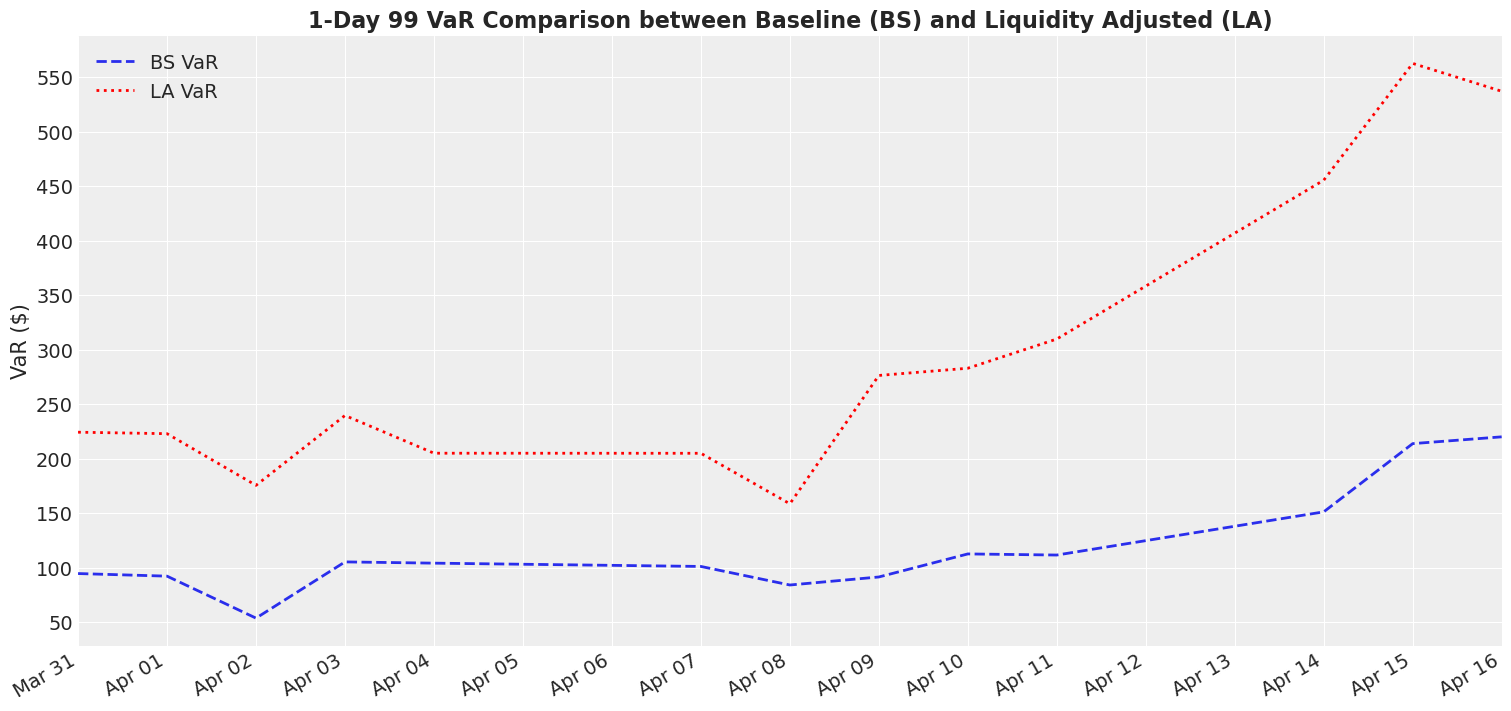

In [99]:
fig, ax = plt.subplots(figsize=(15, 7))

underlying_name = SET_OF_TICKERS[-1]

tmp_df = var_df.copy()
tmp_df['dtVALUATION_DATE'] = pd.to_datetime(tmp_df.sVALUATION_DATE)
tmp_df.dLOSS = tmp_df.dLOSS * -1.

tmp_df2 = tmp_df.copy()
tmp_df2 = tmp_df2.pivot_table(index=['sUNDERLYING', 'iCONFIDENCE_LEVEL', 'dtVALUATION_DATE'], columns='bIS_BASE_SCENARIO', values='dLOSS')
tmp_df2 = tmp_df2[False] / np.minimum(tmp_df2[True], 1.)
tmp_df2.name = 'dRATIO'
#
# tmp_df3 = prices_df.loc[valuation_date_array[:-1], underlying_name]
# tmp_df3.name = 'dPRICES'
# tmp_df3.index.name = 'dtVALUATION_DATE'

# ax2 = ax.twinx()

sns.lineplot(data=tmp_df.loc[(tmp_df.sUNDERLYING == underlying_name) & (tmp_df.bIS_BASE_SCENARIO == True) & (tmp_df.iCONFIDENCE_LEVEL==confidence_level1)],
             x='dtVALUATION_DATE', y='dLOSS', ax=ax, label="BS VaR", linestyle='--', linewidth=2)
sns.lineplot(data=tmp_df.loc[(tmp_df.sUNDERLYING == underlying_name) & (tmp_df.bIS_BASE_SCENARIO == False) & (tmp_df.iCONFIDENCE_LEVEL==confidence_level1)],
             x='dtVALUATION_DATE', y='dLOSS', ax=ax, label="LA VaR", linestyle=':', color='red', linewidth=2)

# sns.lineplot(data=tmp_df2.xs(1, level='iCONFIDENCE_LEVEL').reset_index(), x='dtVALUATION_DATE', y='dRATIO', linestyle='-.', linewidth=1, marker='P', color='grey', label='Ratio of Liquidity to Baseline VaR (RHS)', ax=ax2)

handles1, labels1 = ax.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()

# plt.legend(handles1 + handles2, labels1 + labels2, loc='best')


ax.set_xlabel(r'Underlying Price Shocks (%)')
ax.set_xlabel(None)
ax.set_ylabel(f"{tmp_df.sLOSS_DESC.iloc[0]} ($)")
ax.set_title(rf'1-Day 99 {tmp_df.sLOSS_DESC.iloc[0]} Comparison between Baseline (BS) and Liquidity Adjusted (LA)', fontweight='bold')

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xlim(tmp_df.dtVALUATION_DATE.min(), tmp_df.dtVALUATION_DATE.max())
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
# ax2.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(.1))
# ax2.set_ylabel('Ratio', rotation=270, labelpad=20)

fig.autofmt_xdate()

plt.savefig("daily_var_comparison.pdf", dpi=300)
plt.show()

In [100]:
valuation_date = '20250409'
mask = pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date

df1 = pl_df.loc[mask & (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==False), ['dSPOT_SHIFT', 'dPL']]
df2 = pl_df.loc[mask & (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==True), ['dSPOT_SHIFT', 'dPL']]
df1['Return Assumption'] = 'LA'
df2['Return Assumption'] = 'BS'
simulated_pl_df = pd.concat([df1, df2])
simulated_pl_df = simulated_pl_df.set_index('Return Assumption')

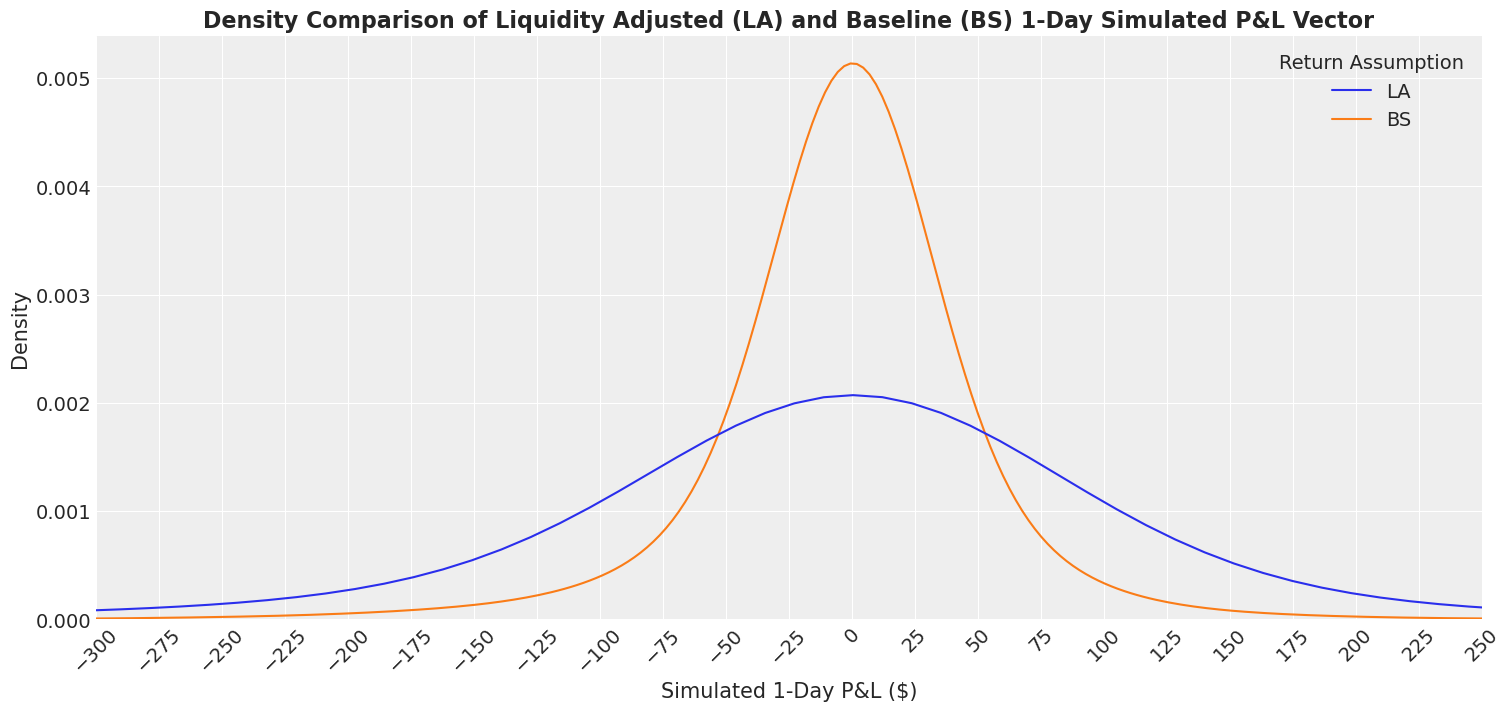

In [101]:
valuation_date = '20250409'
mask = pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date

fig, ax = plt.subplots(figsize=(15, 7))

sns.kdeplot(data=simulated_pl_df.reset_index(), x='dPL', hue='Return Assumption', fill=False, gridsize=500, bw_adjust=5., ax=ax)

ax.set_title(rf'Density Comparison of Liquidity Adjusted (LA) and Baseline (BS) 1-Day Simulated P&L Vector', fontweight='bold')
ax.set_xlabel(r'Simulated 1-Day P&L ($)')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(25 ))
ax.tick_params(axis='x', labelrotation = 45)
plt.setp(ax.get_legend().get_title(), fontsize='14')

plt.xlim(-300, 250)
plt.savefig("simulated_pl.pdf", dpi=300)
plt.show();

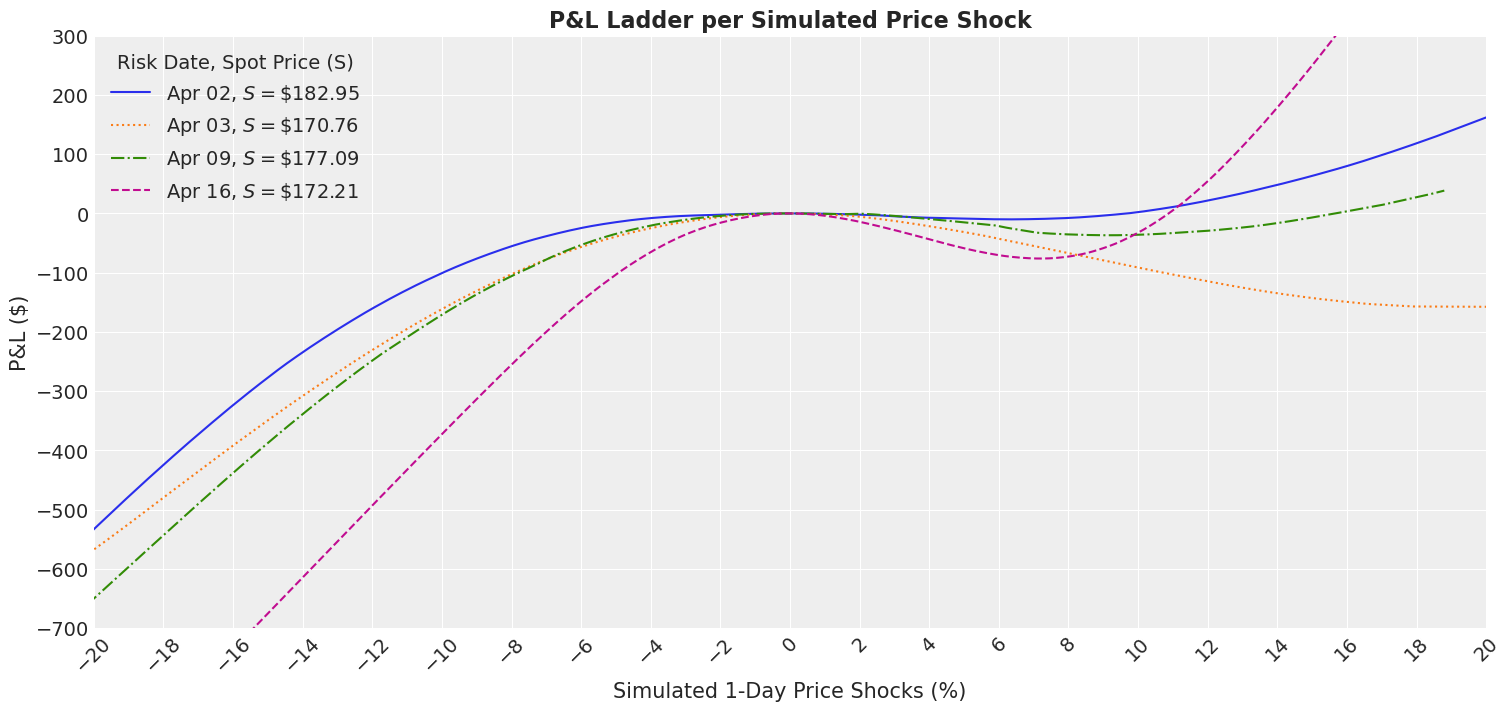

In [102]:
fig, ax = plt.subplots(figsize=(15, 7))

underlying_name = SET_OF_TICKERS[-1]
valuation_date = valuation_date_array[0]

spot_price_t0 = prices_df.xs(valuation_date)[underlying_name]
strike_lower_asian = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][0].dSTRIKE_PRICE
strike_upper_asian = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][1].dSTRIKE_PRICE
strike_lower_hedge = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][2].dSTRIKE_PRICE
strike_upper_hedge = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][3].dSTRIKE_PRICE

dates = [pd.to_datetime('20250402'), pd.to_datetime('20250403'), pd.to_datetime('20250409'), valuation_date_array[-2]]
linestyles = ['-', ':', '-.', '--']

for valuation_date, linestyle in zip(dates, linestyles):
    tmp_df1 = pl_df.loc[
        (pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date.strftime("%Y%m%d")) &
        (pl_df.index.get_level_values('sUNDERLYING')==underlying_name) &
        (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==False),
        ['iSCENARIO_NUM', 'dSPOT_SHIFT', 'dPL', 'dPL_DELTA']
    ]
    tmp_df1.dSPOT_SHIFT = tmp_df1.dSPOT_SHIFT * 100.
    tmp_df1 = tmp_df1.groupby(['iSCENARIO_NUM', 'dSPOT_SHIFT']).sum()
    sns.lineplot(
        data=tmp_df1.reset_index(), x='dSPOT_SHIFT', y='dPL', ax=ax,
        label=rf"{valuation_date.strftime('%b %d')}, $S=\${prices_df.xs(valuation_date)[underlying_name]:.2f}$", linestyle=linestyle)

# tmp_df2 = pl_df.loc[
#     (pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date.strftime("%Y%m%d")) & (pl_df.index.get_level_values('sUNDERLYING')==underlying_name) & (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==True),
#     ['iSCENARIO_NUM', 'dSPOT_SHIFT', 'dPL']
# ]
# tmp_df2.dSPOT_SHIFT = tmp_df2.dSPOT_SHIFT * 100.
# tmp_df2 = tmp_df2.groupby(['iSCENARIO_NUM', 'dSPOT_SHIFT']).sum()
# sns.scatterplot(data=tmp_df2.reset_index(), x='dSPOT_SHIFT', y='dPL', ax=ax, label=r"$\gamma_i = \beta_i = \rho_{i,x} = 0$")

ax.set_xlabel(r'Simulated 1-Day Price Shocks (%)')
ax.set_ylabel('P&L ($)')
ax.set_title("P&L Ladder per Simulated Price Shock", fontweight='bold')

ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(100))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x', labelrotation = 45)
plt.legend(title='Risk Date, Spot Price (S)', title_fontsize=14)
plt.xlim(-20., 20.)
plt.ylim(-700, 300.)

plt.savefig("pl_ladder.pdf", dpi=300)
plt.show()

In [93]:
file_names = ["final_output_1d_horizon.csv", "final_output_5d_horizon.csv", "final_output_10d_horizon.csv", "final_output_15d_horizon.csv", "final_output_20d_horizon.csv"]

df = []
for file_name in file_names:
    df.append(pd.read_csv(os.path.join(os.getcwd(), file_name)))

df = pd.concat(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2800000 entries, 0 to 559999
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   sVALUATION_DATE     int64  
 1   sUNDERLYING         object 
 2   sTYPOLOGY           object 
 3   sSTRATEGY           object 
 4   sPAYOFF             object 
 5   sEXPIRY_DATE        int64  
 6   dSTRIKE_PRICE       float64
 7   iRISK_HORIZON_DAYS  int64  
 8   iQUANTITY           int64  
 9   dSPOT_PRICE         float64
 10  dSPOT_SHIFT         float64
 11  dMONEYNESS          float64
 12  dIMP_VOLATILITY     float64
 13  iSCENARIO_NUM       int64  
 14  dPV_STRESSED        float64
 15  dPV_T0              float64
 16  dDELTA              float64
 17  dPL_DELTA           float64
 18  dPL                 float64
dtypes: float64(10), int64(5), object(4)
memory usage: 427.2+ MB


In [94]:
df2 = df.pivot_table(index=['sVALUATION_DATE', 'iSCENARIO_NUM'], columns='iRISK_HORIZON_DAYS', values='dPL', aggfunc='sum').copy()
df2

iRISK_HORIZON_DAYS                     1           5            10  \
sVALUATION_DATE iSCENARIO_NUM                                        
20250331        0             -155.624553 -546.510803 -1248.189231   
                1              -58.108191   -2.986991  -226.746214   
                2              -11.740356  -16.172124  -109.096102   
                3               -1.262869   -0.861890  -213.284635   
                4               -3.499567 -105.369571  -126.896060   
...                                   ...         ...          ...   
20250417        9995           157.258964  157.258964   157.258964   
                9996            -0.666375   -0.666375    -0.666375   
                9997          -337.267232 -337.267232  -337.267232   
                9998           -32.882960  -32.882960   -32.882960   
                9999            53.790950   53.790950    53.790950   

iRISK_HORIZON_DAYS                      15           20  
sVALUATION_DATE iSCENARIO_NUM                            
20250331        0             -1892.651197 -2191.332323  
                1                -9.423797   -15.815949  
                2              -109.050205  -154.197606  
                3               -20.377406   -77.125297  
                4               -68.072600   -60.012048  
...                                    ...          ...  
20250417        9995            157.258964   157.258964  
                9996             -0.666375    -0.666375  
                9997           -337.267232  -337.267232  
                9998            -32.882960   -32.882960  
                9999             53.790950    53.790950  

[140000 rows x 5 columns]

In [96]:
xi = np.array(df2.columns)
yi = np.quantile(df2.xs(20250331).to_numpy().T, q=0.01, axis=1)
x = np.linspace(1, 20, 20, dtype=np.int64)
yi

array([ -205.97794382,  -824.82781379, -1369.11848109, -1711.16693586,
       -1899.28049868])

In [97]:
from scipy.interpolate import pchip_interpolate

In [98]:
y = pchip_interpolate(xi=xi, yi=yi, x=x)
y

array([ -205.97794382,  -377.04532533,  -538.63627883,  -688.61053232,
        -824.82781379,  -950.31120735, -1068.69917541, -1178.77451342,
       -1279.32001683, -1369.11848109, -1450.69635325, -1526.71098396,
       -1596.14152407, -1657.96712442, -1711.16693586, -1758.24391637,
       -1801.66645919, -1840.36186803, -1873.25744662, -1899.28049868])

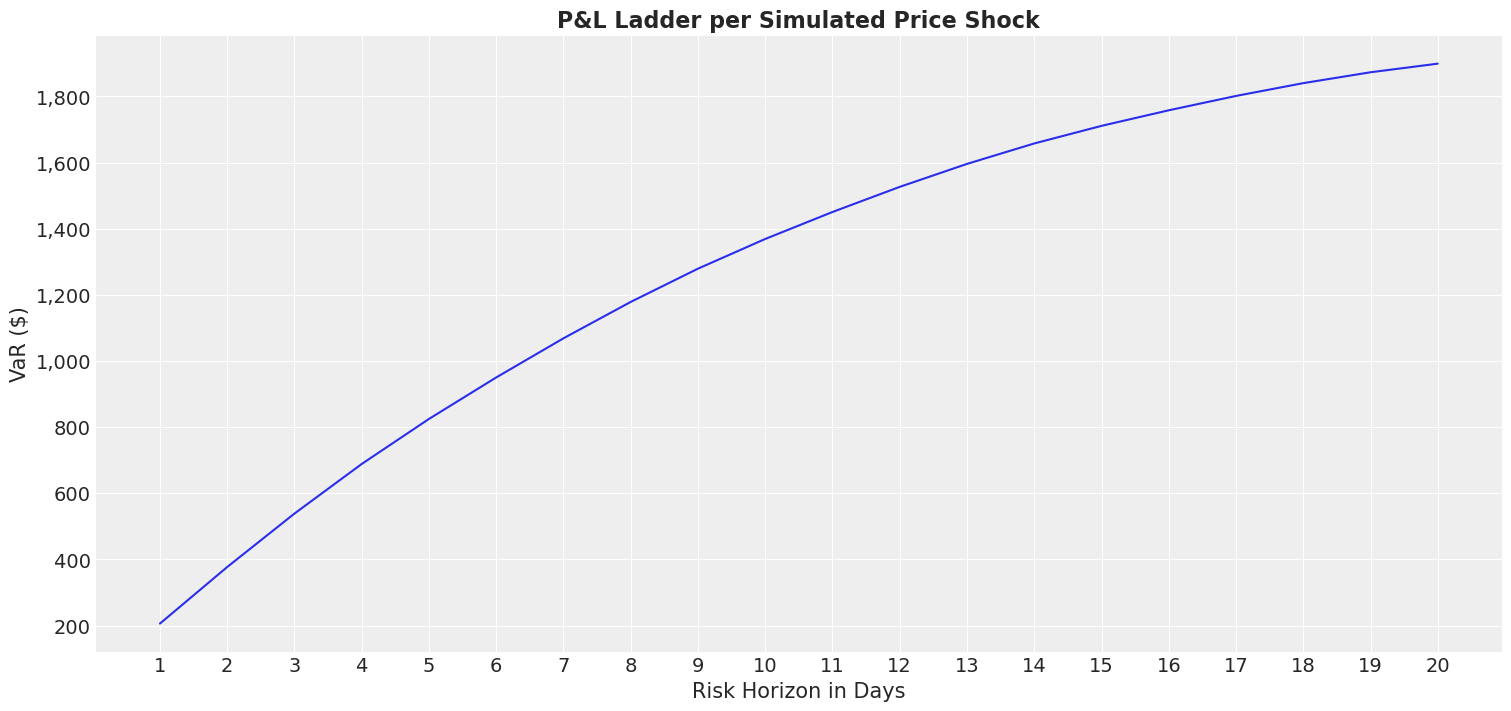

In [109]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(x=x, y=y * -1., ax=ax)

ax.set_xlabel(r'Risk Horizon in Days')
ax.set_ylabel('VaR ($)')
ax.set_title("P&L Ladder per Simulated Price Shock", fontweight='bold')

ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(200))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.show()